# End-to-End Latent JacobianODE on Partially Observed Lorenz

This notebook demonstrates training a **Latent JacobianODE** model on partially observed,
noisy Lorenz data. The architecture jointly trains:

1. **Encoder** (MLPAutoencoder): Maps sliding windows of 1D noisy observations → latent vectors
2. **Jacobian MLP**: Predicts Jacobian matrices in the learned latent space
3. **Decoder**: Maps latent vectors back to observation windows

The prediction loss backpropagates end-to-end through decoder → JacobianODEint → encoder,
forcing the encoder to discover a latent representation where Jacobian-based dynamics
prediction actually works.

**Key hyperparameters** are configured via Hydra overrides — this notebook shows how
to set every relevant knob.

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

In [3]:
from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    make_model,
    train_model,
)
from JacobianODE.models.latent_jacobian import LitLatentJacobianODE
from JacobianODE.fnn import compute_variances, compute_s_dim

In [4]:
seed_everything(42)

42

## 1. Generate Lorenz Data (Partially Observed + Noisy)

We generate full 3D Lorenz trajectories via `dysts`, then restrict the
data pipeline to observe **only the x-coordinate** (index 0). Observation
noise is added during postprocessing.

In [5]:
# ----------------------------------------------------------------
# Hyperparameters: Data generation
# ----------------------------------------------------------------
OBS_NOISE = 0.05        # Observation noise std (added to observed dim)
OBSERVED_INDICES = [0]  # Which Lorenz dimensions to observe (0 = x only)
N_PERIODS = 12          # How many Lorenz periods to simulate
PTS_PER_PERIOD = 100    # Temporal resolution
NUM_ICS = 32            # Number of independent trajectories

In [6]:
# ----------------------------------------------------------------
# Hyperparameters: Encoder / Latent space
# ----------------------------------------------------------------
N_LATENT = 10              # Latent space dimension
TIME_WINDOW = 50          # Encoder input window size (observation time steps)
# ENCODER_SHAPE = [128, 128]  # Encoder/decoder hidden layer sizes
ENCODER_SHAPE = [256, 1024, 2048, 2048]
PREDICTION_STEPS = 10      # How many latent steps to predict forward

In [7]:
# ----------------------------------------------------------------
# Hyperparameters: Jacobian MLP
# ----------------------------------------------------------------
JAC_HIDDEN_DIM = [256, 1024, 2048, 2048]  # Jacobian MLP hidden dims
JAC_NUM_LAYERS = 4
JAC_ACTIVATION = 'silu'

In [8]:
# ----------------------------------------------------------------
# Hyperparameters: Training
# ----------------------------------------------------------------
BATCH_SIZE = 16
MAX_EPOCHS = 200
LIMIT_TRAIN_BATCHES = 500
ACCUMULATE_GRAD_BATCHES = 1
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

ENCODER_WARMUP_EPOCHS = 25  # Train autoencoder reconstruction only before
                            # introducing Jacobian prediction, so the latent
                            # space is stable when the Jacobian MLP starts learning
TRAJ_INIT_STEPS = 15       # Number of init steps for JacobianODEint
LOOP_CLOSURE_WEIGHT = 0.01 # Weight for loop closure regularizer
JAC_CONSISTENCY_WEIGHT = 0.0  # Weight for Jacobian-consistency regularizer
FNN_WEIGHT = 0.0               # Weight for FNN latent-geometry regularizer (Gilpin NeurIPS 2020)

LEARN_R2_WEIGHT          = False  # Learn weight for R²-like loss group (homoscedastic UW)
LEARN_LOOP_CLOSURE_WEIGHT = False  # Learn weight for loop closure loss (homoscedastic UW)
LEARN_FNN_WEIGHT         = False  # Learn weight for FNN regularization (homoscedastic UW)
LEARN_JAC_CONS_WEIGHT    = False  # Learn weight for Jacobian consistency loss (homoscedastic UW)
LEARN_JAC_NORM_WEIGHT    = False  # Learn weight for Jacobian norm penalty (homoscedastic UW)
LOG_VAR_INIT             = 'naive'  # 'naive' or 'auto' (auto sets log_var = log(initial_loss))
INTERP_PTS = 4             # Interpolation points for JacobianODE integration
INNER_N = 20               # Inner integration points
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"  # Directory for checkpoints and cached data

In [9]:
# ----------------------------------------------------------------
# Hyperparameters: Training sequence length
# ----------------------------------------------------------------
# The sequence length (seq_length) fed to the model must be long enough
# for the encoder + JacobianODE sub-window:
#   After encoding: T' = seq_length - TIME_WINDOW + 1
#   JacobianODE window: TRAJ_INIT_STEPS + PREDICTION_STEPS
#   Need: T' >= TRAJ_INIT_STEPS + PREDICTION_STEPS
#   So:   seq_length >= TIME_WINDOW + TRAJ_INIT_STEPS + PREDICTION_STEPS - 1
MIN_SEQ_LENGTH = TIME_WINDOW + TRAJ_INIT_STEPS + PREDICTION_STEPS - 1
SEQ_LENGTH = max(MIN_SEQ_LENGTH + 20, 80)  # Add headroom for random sub-window sampling
print(f"Minimum seq_length: {MIN_SEQ_LENGTH}")
print(f"Using seq_length:   {SEQ_LENGTH}")
print(f"Latent trajectory length T' = {SEQ_LENGTH - TIME_WINDOW + 1}")
print(f"JacobianODE window = {TRAJ_INIT_STEPS} + {PREDICTION_STEPS} = {TRAJ_INIT_STEPS + PREDICTION_STEPS}")

Minimum seq_length: 74
Using seq_length:   94
Latent trajectory length T' = 45
JacobianODE window = 15 + 10 = 25


## 2. Load and Configure via Hydra

All hyperparameters are set through Hydra config overrides. The `model=latent_mlp`
config selects the latent JacobianODE architecture.

In [ ]:
overrides = [
    # --- Model selection ---
    "model=latent_mlp",

    # --- Encoder hyperparameters ---
    f"model.encoder.n_latent={N_LATENT}",
    f"model.encoder.time_window={TIME_WINDOW}",
    f"model.encoder.n_features={len(OBSERVED_INDICES)}",
    f"model.encoder.network_shape={ENCODER_SHAPE}",

    # --- Jacobian MLP hyperparameters ---
    f"model.params.hidden_dim={JAC_HIDDEN_DIM}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",

    # --- Prediction steps ---
    f"model.prediction_steps={PREDICTION_STEPS}",

    # --- Data: Lorenz with partial observation ---
    "data=dysts",
    "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
    f"data.trajectory_params.n_periods={N_PERIODS}",
    f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"data.trajectory_params.num_ics={NUM_ICS}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    f"data.train_test_params.delay_embedding_params.observed_indices={list(OBSERVED_INDICES)}",
    "data.train_test_params.delay_embedding_params.n_delays=1",

    # --- Data normalization (critical for encoder warmup convergence) ---
    "data.postprocessing.normalize=True",

    # --- Training sequence length ---
    f"data.train_test_params.seq_length={SEQ_LENGTH}",

    # --- Save directory ---
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.logger_save_dirs={SAVE_DIR}",

    # --- Training hyperparameters ---
    f"training.batch_size={BATCH_SIZE}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    f"training.lightning.loop_closure_weight={LOOP_CLOSURE_WEIGHT}",
    f"training.lightning.jac_consistency_weight={JAC_CONSISTENCY_WEIGHT}",
    f"training.lightning.fnn_weight={FNN_WEIGHT}",

    # --- Homoscedastic uncertainty weighting ---
    f"training.lightning.learn_r2_weight={LEARN_R2_WEIGHT}",
    f"training.lightning.learn_loop_closure_weight={LEARN_LOOP_CLOSURE_WEIGHT}",
    f"training.lightning.learn_fnn_weight={LEARN_FNN_WEIGHT}",
    f"training.lightning.learn_jac_cons_weight={LEARN_JAC_CONS_WEIGHT}",
    f"training.lightning.learn_jac_norm_weight={LEARN_JAC_NORM_WEIGHT}",
    f"training.lightning.log_var_init={LOG_VAR_INIT}",
    "training.lightning.loop_closure_training=True",
    "training.lightning.trajectory_training=True",

    # --- Teacher forcing ---
    "training.lightning.alpha_teacher_forcing=1",
    "training.lightning.teacher_forcing_annealing=True",
    "training.lightning.gamma_teacher_forcing=0.999",

    # --- JacobianODEint settings ---
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    "training.lightning.jacobianODEint_kwargs.inner_path=line",

    # --- Trainer params ---
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    "training.trainer_params.limit_val_batches=50",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",

    # --- Early stopping ---
    "training.early_stopping.early_stopping_patience=5",
]

cfg = load_config(overrides=overrides)
cfg = initialize_config(cfg)

print("Lightning target:", cfg.training.lightning._target_)
print(f"Jacobian MLP: input_dim={cfg.model.params.input_dim}, output_dim={cfg.model.params.output_dim}")
print(f"Encoder: n_latent={cfg.model.encoder.n_latent}, time_window={cfg.model.encoder.time_window}")
print(f"Normalize: {cfg.data.postprocessing.normalize}")

In [11]:
# Print full resolved config for reference
print(OmegaConf.to_yaml(cfg))

logger: wandb
wandb_entity: JacobianODE
training:
  batch_size: 16
  run_number: 0
  lightning:
    _target_: JacobianODE.models.latent_jacobian.LitLatentJacobianODE
    optimizer: AdamW
    optimizer_kwargs:
      lr: 0.0001
      weight_decay: 0.0001
    use_scheduler: true
    min_lr: 1.0e-06
    k_scale: 1
    gradient_clip_val: 1.0
    gradient_clip_algorithm: norm
    alpha_teacher_forcing: 1
    teacher_forcing_annealing: true
    gamma_teacher_forcing: 0.999
    teacher_forcing_update_interval: 5
    teacher_forcing_steps: 1
    min_alpha_teacher_forcing: 0
    alpha_validation: 0
    obs_noise_scale: 0
    jac_penalty: 0.0
    jac_norm_ord: fro
    loop_closure_training: true
    loop_closure_weight: 0.01
    n_loop_pts: 20
    mix_trajectories: true
    loop_closure_interp_pts: 20
    loop_closure_int_method: Trapezoid
    n_loops: null
    jacobianODEint_kwargs:
      traj_init_steps: 15
      inner_path: line
      inner_N: 20
      interp_pts: 4
    log_interval: 100
    t

## 3. Generate Trajectories and Create DataLoaders

In [12]:
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1200, 3)
Time step dt = 0.0150


In [ ]:
# Postprocess: adds observation noise, then normalize
values = postprocess_data(cfg, sol["values"])

# Normalize data (matches run_jacobians.py pattern)
from JacobianODE.jacobians.data.processing import normalize_data
values, mu, sigma = normalize_data(values)
print(f"Postprocessed shape: {values.shape}")
print(f"Normalization: mu={mu:.4f}, sigma={sigma:.4f}")

In [14]:
# Create dataloaders
# The delay_embedding_params in the config will select observed_indices=[0]
# so the dataloader yields (B, seq_length, 1) tensors
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True)

# Inspect a batch
sample_batch = next(iter(train_dl))
print(f"\nBatch shape: {sample_batch.shape}")
print(f"  -> (batch_size={sample_batch.shape[0]}, seq_length={sample_batch.shape[1]}, n_obs_dims={sample_batch.shape[2]})")

Sequence Indices:   0%|          | 0/1106 [00:00<?, ?it/s]

Train dataset shape: torch.Size([24332, 94, 1])
Validation dataset shape: torch.Size([7742, 94, 1])
Test dataset shape: torch.Size([3318, 94, 1])
Train trajectories dataset shape: torch.Size([22, 1200, 1])
Validation trajectories dataset shape: torch.Size([7, 1200, 1])
Test trajectories dataset shape: torch.Size([3, 1200, 1])

Batch shape: torch.Size([16, 94, 1])
  -> (batch_size=16, seq_length=94, n_obs_dims=1)


## 4. Visualize the Data

Compare the full 3D Lorenz attractor with our single noisy observation.

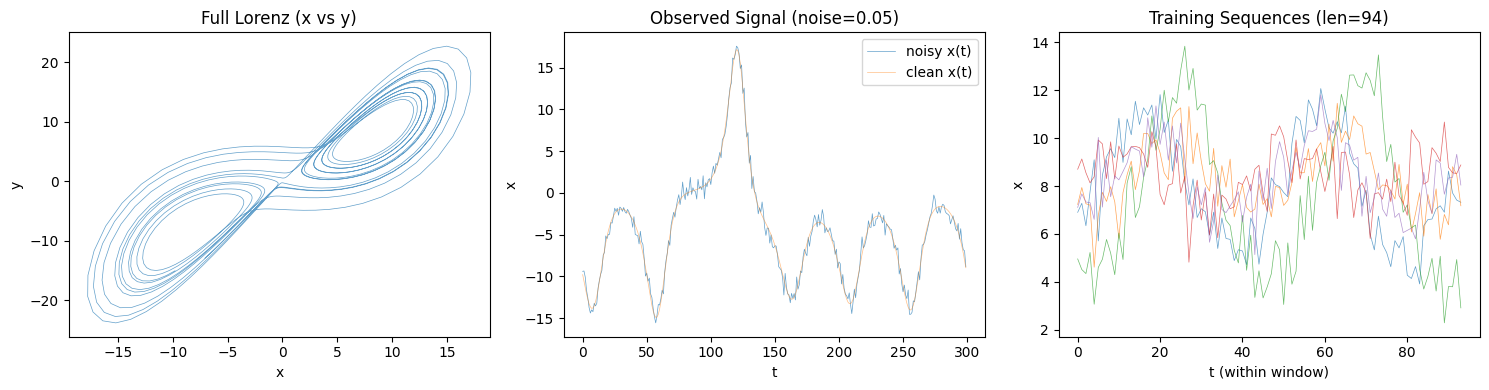

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full Lorenz attractor (trial 0)
traj_full = sol["values"][0]
axes[0].plot(traj_full[:, 0], traj_full[:, 1], lw=0.5, alpha=0.7)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("Full Lorenz (x vs y)")

# Observed signal (x only, with noise)
axes[1].plot(values[0, :300, 0], lw=0.5, alpha=0.7, label="noisy x(t)")
axes[1].plot(sol["values"][0, :300, 0], lw=0.5, alpha=0.5, label="clean x(t)")
axes[1].set_xlabel("t"); axes[1].set_ylabel("x")
axes[1].set_title(f"Observed Signal (noise={OBS_NOISE})")
axes[1].legend()

# A training batch
for i in range(min(5, sample_batch.shape[0])):
    axes[2].plot(sample_batch[i, :, 0].numpy(), lw=0.5, alpha=0.7)
axes[2].set_xlabel("t (within window)"); axes[2].set_ylabel("x")
axes[2].set_title(f"Training Sequences (len={SEQ_LENGTH})")

plt.tight_layout()
plt.show()

## 5. Create the Latent JacobianODE Model

`make_model` instantiates the Jacobian MLP, encoder, and wraps them in
`LitLatentJacobianODE` — all driven by the Hydra config.

In [ ]:
# ----------------------------------------------------------------
# Precompute true Lyapunov exponents from the full system
# ----------------------------------------------------------------
# In partially observed settings, we can't compute true Jacobians from the
# batch (the batch only has 1 observed dimension). But Lyapunov exponents
# are coordinate-invariant, so we precompute them from the full 3D system
# and use them as a training diagnostic.

TRUE_LYAPUNOV = [0.91, 0.0, -14.57]  # Known Lorenz exponents (sigma=10, rho=28, beta=8/3)

# Create the model with true Lyapunov exponents for logging
lit_model = make_model(cfg, dt=dt, eq=eq, mu=mu, sigma=sigma, verbose=True)
lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
lit_model.encoder_warmup_epochs = ENCODER_WARMUP_EPOCHS

print(f"\nModel type: {type(lit_model).__name__}")
print(f"Encoder type: {type(lit_model.encoder).__name__}")
print(f"Encoder time_window: {lit_model.encoder.time_window}")
print(f"Encoder n_latent: {lit_model.encoder.n_latent}")
print(f"Prediction steps: {lit_model.prediction_steps}")
print(f"Encoder warmup epochs: {lit_model.encoder_warmup_epochs}")
print(f"dt: {lit_model.dt}")
print(f"True Lyapunov exponents: {TRUE_LYAPUNOV}")

# Count parameters
encoder_params = sum(p.numel() for p in lit_model.encoder.parameters())
jac_params = sum(p.numel() for p in lit_model.model.parameters())
total_params = sum(p.numel() for p in lit_model.parameters())
print(f"\nParameter counts:")
print(f"  Encoder:      {encoder_params:,}")
print(f"  Jacobian MLP: {jac_params:,}")
print(f"  Total:        {total_params:,}")

## 6. Sanity Check: Forward Pass

Verify shapes through the full pipeline before training.

In [20]:
# lit_model.cpu().eval()

# with torch.no_grad():
#     # Encode
#     z = lit_model.encode_trajectory(sample_batch)
#     print(f"Encoded latent shape: {z.shape}")
#     print(f"  (B={z.shape[0]}, T'={z.shape[1]}, D_latent={z.shape[2]})")

#     # Compute Jacobians in latent space
#     jacs = lit_model.compute_jacobians(z)
#     print(f"Jacobians shape: {jacs.shape}")

#     # Decode
#     decoded = lit_model.decode_trajectory(z[:, :5, :])
#     print(f"Decoded shape: {decoded.shape}")

#     # Full training step
#     result = lit_model.trajectory_model_step(sample_batch)
#     print(f"\nTrajectory step loss: {result['loss'].item():.6f}")
#     print(f"Metrics: {result['metric_vals']}")

In [21]:
# # Check gradient flow (on CPU to avoid initializing CUDA before training)
# lit_model.cpu().train()
# loss = lit_model.training_step(sample_batch, batch_idx=0)
# loss.backward()

# encoder_grad = max(p.grad.abs().max().item() for p in lit_model.encoder.parameters() if p.grad is not None)
# jac_grad = max(p.grad.abs().max().item() for p in lit_model.model.parameters() if p.grad is not None)
# print(f"Training loss: {loss.item():.6f}")
# print(f"Max encoder gradient: {encoder_grad:.6e}")
# print(f"Max Jacobian MLP gradient: {jac_grad:.6e}")

# lit_model.zero_grad()

## 7. Train the Model

Training uses PyTorch Lightning with W&B logging. Teacher forcing starts at
`alpha=1` (fully guided) and anneals based on the estimated stability of the
latent dynamics.

**Note**: Set `project` and `entity` to your W&B workspace, or set
`WANDB_MODE=offline` to skip logging.

In [22]:
import os
import wandb
# Uncomment to disable W&B logging:
# os.environ["WANDB_MODE"] = "offline"

# Clean up any stale W&B run from a previous interrupt
try:
    wandb.finish(quiet=True)
except Exception:
    pass

In [ ]:
# Re-create model (sanity check cells above may have consumed gradients)
lit_model = make_model(cfg, dt=dt, eq=eq, mu=mu, sigma=sigma, verbose=True)
lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
lit_model.encoder_warmup_epochs = ENCODER_WARMUP_EPOCHS

train_model(
    cfg=cfg,
    lit_model=lit_model,
    train_dataloaders=train_dl,
    val_dataloaders=val_dl,
    name=f"latent_jac_lorenz_x_n{N_LATENT}_w{TIME_WINDOW}_p{PREDICTION_STEPS}",
    project="LatentLorenz__JacobianODE",
    entity="JacobianODE",  # Set to your W&B entity
)

In [25]:
import warnings
warnings.filterwarnings("ignore", message=".*BrokenPipeError.*")

Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x14bef8438650>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 14be99ec5c70, raw_cell="import warnings
warnings.filterwarnings("ignore", .." transformed_cell="import warnings
warnings.filterwarnings("ignore", .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B7b22686f73744e616d65223a22656e676167696e672d6e6f6465227d/home/eisenaj/code/JacobianODE/_jupyter/Latent%20JacobianODE%20%28Lorenz%20-%20partial%20obs%29.ipynb#Y245sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x14bef8438650>> (for post_run_cell), with arguments args (<ExecutionResult object at 14be99eb6f90, execution_count=25 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 14be99ec5c70, raw_cell="import warnings
warnings.filterwarnings("ignore", .." transformed_cell="import warnings
warnings.filterwarnings("ignore", .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B7b22686f73744e616d65223a22656e676167696e672d6e6f6465227d/home/eisenaj/code/JacobianODE/_jupyter/Latent%20JacobianODE%20%28Lorenz%20-%20partial%20obs%29.ipynb#Y245sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

## 8. Evaluate the Trained Model

After training, we evaluate:
1. Observation-space prediction quality (MSE, R2, MASE)
2. Latent space structure (PCA visualization)
3. Lyapunov exponent comparison (coordinate-invariant)
4. S_dim diagnostic (if full state available)

In [24]:
batch

Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x14bef8438650>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 14be99eaa7e0, raw_cell="batch" transformed_cell="batch
" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B7b22686f73744e616d65223a22656e676167696e672d6e6f6465227d/home/eisenaj/code/JacobianODE/_jupyter/Latent%20JacobianODE%20%28Lorenz%20-%20partial%20obs%29.ipynb#Y246sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

tensor([[[-1.1027],
         [-0.2694],
         [-0.3223],
         ...,
         [ 8.6669],
         [ 7.5231],
         [ 8.1756]],

        [[ 0.0120],
         [-2.3633],
         [-0.9817],
         ...,
         [ 7.3082],
         [ 7.3251],
         [ 8.4302]],

        [[-2.0470],
         [ 0.8495],
         [-0.3131],
         ...,
         [-8.0102],
         [-8.6756],
         [-7.2328]],

        ...,

        [[ 0.2629],
         [-0.0606],
         [-1.5091],
         ...,
         [-7.8323],
         [-7.7985],
         [-7.1185]],

        [[-0.3223],
         [ 0.3871],
         [ 1.5634],
         ...,
         [ 8.1756],
         [ 5.9721],
         [ 7.2843]],

        [[-0.9817],
         [-0.0984],
         [ 0.3009],
         ...,
         [ 8.4302],
         [ 7.3167],
         [ 6.7050]]])

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x14bef8438650>> (for post_run_cell), with arguments args (<ExecutionResult object at 14be99ea92b0, execution_count=24 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 14be99eaa7e0, raw_cell="batch" transformed_cell="batch
" store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B7b22686f73744e616d65223a22656e676167696e672d6e6f6465227d/home/eisenaj/code/JacobianODE/_jupyter/Latent%20JacobianODE%20%28Lorenz%20-%20partial%20obs%29.ipynb#Y246sdnNjb2RlLXJlbW90ZQ%3D%3D> result=tensor([[[-1.1027],
         [-0.2694],
         [-0.3223],
         ...,
         [ 8.6669],
         [ 7.5231],
         [ 8.1756]],

        [[ 0.0120],
         [-2.3633],
         [-0.9817],
         ...,
         [ 7.3082],
         [ 7.3251],
         [ 8.4302]],

        [[-2.0470],
         [ 0.8495],
         [-0.3131],
         ...,
         [-

BrokenPipeError: [Errno 32] Broken pipe

In [19]:
lit_model.eval()

# Evaluate on validation set
val_losses = []
all_z = []
all_obs = []

with torch.no_grad():
    for batch in val_dl:
        result = lit_model.trajectory_model_step(
            batch,
            alpha_teacher_forcing=0,  # No teacher forcing at eval
            obs_noise_scale=0,
        )
        val_losses.append(result['loss'].item())

        z = lit_model.encode_trajectory(batch)
        all_z.append(z)
        all_obs.append(batch)

print(f"Validation MSE (no teacher forcing): {np.mean(val_losses):.6f}")

# Concatenate
z_all = torch.cat(all_z, dim=0)  # (N, T', D_latent)
obs_all = torch.cat(all_obs, dim=0)

Error in callback <bound method _WandbInit._resume_backend of <wandb.sdk.wandb_init._WandbInit object at 0x14bef8438650>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 14befd1bafc0, raw_cell="lit_model.eval()

# Evaluate on validation set
val.." transformed_cell="lit_model.eval()

# Evaluate on validation set
val.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B7b22686f73744e616d65223a22656e676167696e672d6e6f6465227d/home/eisenaj/code/JacobianODE/_jupyter/Latent%20JacobianODE%20%28Lorenz%20-%20partial%20obs%29.ipynb#X40sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

KeyboardInterrupt: 

Error in callback <bound method _WandbInit._pause_backend of <wandb.sdk.wandb_init._WandbInit object at 0x14bef8438650>> (for post_run_cell), with arguments args (<ExecutionResult object at 14befd1b9250, execution_count=19 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 14befd1bafc0, raw_cell="lit_model.eval()

# Evaluate on validation set
val.." transformed_cell="lit_model.eval()

# Evaluate on validation set
val.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2B7b22686f73744e616d65223a22656e676167696e672d6e6f6465227d/home/eisenaj/code/JacobianODE/_jupyter/Latent%20JacobianODE%20%28Lorenz%20-%20partial%20obs%29.ipynb#X40sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

### 8a. Latent Space Visualization (PCA)

In [ ]:
from sklearn.decomposition import PCA

# Flatten latent trajectories for PCA
z_flat = z_all.reshape(-1, z_all.shape[-1]).numpy()

pca = PCA(n_components=3)
z_pca = pca.fit_transform(z_flat)

fig = plt.figure(figsize=(14, 5))

# 3D PCA of latent space
ax1 = fig.add_subplot(131, projection='3d')
n_plot = min(5000, len(z_pca))
idx = np.random.choice(len(z_pca), n_plot, replace=False)
ax1.scatter(z_pca[idx, 0], z_pca[idx, 1], z_pca[idx, 2], s=0.5, alpha=0.3)
ax1.set_title("Latent Space (PCA)")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2"); ax1.set_zlabel("PC3")

# 2D projections
ax2 = fig.add_subplot(132)
ax2.scatter(z_pca[idx, 0], z_pca[idx, 1], s=0.5, alpha=0.3)
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2")
ax2.set_title("Latent PC1 vs PC2")

# Variance explained
ax3 = fig.add_subplot(133)
ax3.bar(range(1, 4), pca.explained_variance_ratio_)
ax3.set_xlabel("Component"); ax3.set_ylabel("Variance Explained")
ax3.set_title(f"PCA Variance ({pca.explained_variance_ratio_.sum():.1%} total)")

plt.tight_layout()
plt.show()

print(f"PCA explained variance ratios: {pca.explained_variance_ratio_}")

### 8b. Lyapunov Exponent Comparison

The Lorenz system has known Lyapunov exponents:
- $\lambda_1 \approx +0.91$ (positive → chaos)
- $\lambda_2 \approx 0$ (marginal)
- $\lambda_3 \approx -14.57$ (strongly contracting)

We compute the predicted Lyapunov spectrum from the latent Jacobians via
QR decomposition. This comparison is **coordinate-invariant** — the latent
Jacobians don't need to match the true ones entry-by-entry, only the
eigenvalue spectrum matters.

In [ ]:
# True Lorenz Lyapunov exponents (standard parameters sigma=10, rho=28, beta=8/3)
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]

# Compute from latent Jacobians using a long validation trajectory
with torch.no_grad():
    # Use all validation latent points from first few trajectories
    z_long = z_all[:5].reshape(-1, z_all.shape[-1]).unsqueeze(0)  # (1, T_long, D_lat)
    jacs_long = lit_model.compute_jacobians(z_long)[0]  # (T_long, D_lat, D_lat)
    pred_lyap = LitLatentJacobianODE.compute_lyapunov_exponents(jacs_long, dt)

print("Predicted Lyapunov exponents (latent space):")
for i, le in enumerate(pred_lyap):
    print(f"  lambda_{i+1} = {le.item():+.4f}")

print(f"\nTrue Lorenz Lyapunov exponents:")
for i, le in enumerate(TRUE_LYAPUNOV):
    print(f"  lambda_{i+1} = {le:+.4f}")

print(f"\nNote: The latent space has {N_LATENT} dimensions, so {N_LATENT} exponents")
print(f"are computed. Only the top {len(TRUE_LYAPUNOV)} should be compared to the true values.")
print(f"Extra exponents should be strongly negative (contracting dimensions).")

In [ ]:
# Plot Lyapunov spectrum
fig, ax = plt.subplots(figsize=(8, 4))

pred_np = pred_lyap.numpy()
ax.bar(np.arange(len(pred_np)) - 0.15, pred_np, width=0.3, label="Predicted (latent)", alpha=0.8)

# Overlay true values (padded with NaN for extra dims)
true_padded = TRUE_LYAPUNOV + [np.nan] * (N_LATENT - len(TRUE_LYAPUNOV))
true_mask = [not np.isnan(v) for v in true_padded]
true_vals = [v for v in true_padded if not np.isnan(v)]
ax.bar(np.arange(len(TRUE_LYAPUNOV)) + 0.15, true_vals, width=0.3, label="True (Lorenz)", alpha=0.8)

ax.axhline(y=0, color='k', linestyle='--', lw=0.5)
ax.set_xlabel("Exponent index")
ax.set_ylabel("Lyapunov exponent")
ax.set_title("Lyapunov Spectrum: Predicted vs True")
ax.legend()
plt.tight_layout()
plt.show()

### 8c. S_dim Diagnostic

Since we have the full 3D Lorenz state available (benchmark setting), we can
compute `S_dim` — a measure of how well the latent variance distribution
matches the true state's variance distribution. Values close to 1.0 indicate
good alignment.

**Caveat**: S_dim requires knowing the true variance distribution, so it's
only usable as a diagnostic, not for hyperparameter selection in real settings.

In [ ]:
# Get full-state trajectories for comparison
# sol["values"] has shape (n_trials, T, 3) — full Lorenz state
full_state = sol["values"][:5].reshape(-1, 3)  # flatten trials

# Latent embeddings (same trials)
latent_flat = z_all[:5].reshape(-1, N_LATENT).numpy()

# Note: compute_variances expects (n_samples, n_features)
vars_true = compute_variances(full_state, normalize=True)
vars_latent = compute_variances(latent_flat, normalize=True)

# Pad the shorter variance vector with zeros for S_dim comparison
max_len = max(len(vars_true), len(vars_latent))
vars_true_padded = np.pad(vars_true, (0, max_len - len(vars_true)))
vars_latent_padded = np.pad(vars_latent, (0, max_len - len(vars_latent)))

s_dim = compute_s_dim(vars_true_padded, vars_latent_padded)
print(f"S_dim = {s_dim:.4f}")
print(f"  (1.0 = perfect variance alignment, 0.0 = no alignment)")

# Plot variance spectra
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(range(1, len(vars_true) + 1), vars_true, 'o-', label=f"True state ({len(vars_true)}D)")
ax.plot(range(1, len(vars_latent) + 1), vars_latent, 's-', label=f"Latent ({len(vars_latent)}D)")
ax.set_xlabel("Component (sorted)")
ax.set_ylabel("Normalized variance")
ax.set_title(f"Variance Spectrum (S_dim = {s_dim:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

### 8d. Prediction Visualization

Visualize the model's observation-space predictions on held-out data.

In [ ]:
lit_model.eval()

# Get a test batch
test_batch = next(iter(test_dl))

with torch.no_grad():
    # Encode
    z_test = lit_model.encode_trajectory(test_batch)

    # Run JacobianODEint prediction on a sub-window
    traj_init = cfg.training.lightning.jacobianODEint_kwargs.traj_init_steps
    window_len = traj_init + PREDICTION_STEPS
    z_window = z_test[:, :window_len, :]  # Take first window

    from JacobianODE.jacobians.jacobianODE import JacobianODEint
    jac_odeint = JacobianODEint(lit_model.compute_jacobians, dt)
    z_pred = jac_odeint.generate_dynamics(
        z_window,
        alpha_teacher_forcing=0,
        fast_mode=True,
        traj_init_steps=traj_init,
        interp_pts=INTERP_PTS,
        inner_N=INNER_N,
        inner_path='line',
    )

    # Decode predicted and true
    z_pred_crop = z_pred[:, traj_init:, :]
    z_true_crop = z_window[:, traj_init:, :]
    decoded_pred = lit_model.decode_trajectory(z_pred_crop)
    decoded_true = lit_model.decode_trajectory(z_true_crop)

In [ ]:
# Plot predictions for first few batch elements
n_show = min(4, decoded_pred.shape[0])
fig, axes = plt.subplots(n_show, 1, figsize=(12, 3 * n_show), sharex=True)
if n_show == 1:
    axes = [axes]

for i in range(n_show):
    # Flatten the (prediction_steps, time_window, n_features) to a 1D signal
    pred_signal = decoded_pred[i].reshape(-1).numpy()
    true_signal = decoded_true[i].reshape(-1).numpy()

    axes[i].plot(true_signal, label="True (decoded from true z)", alpha=0.8)
    axes[i].plot(pred_signal, '--', label="Predicted (decoded from JacODE z)", alpha=0.8)
    axes[i].set_ylabel("x(t)")
    axes[i].set_title(f"Batch element {i}")
    if i == 0:
        axes[i].legend()

axes[-1].set_xlabel("Time index")
fig.suptitle(f"Observation-Space Predictions ({PREDICTION_STEPS} latent steps forward)", y=1.01)
plt.tight_layout()
plt.show()

## 9. Hyperparameter Reference

Summary of all tunable hyperparameters for the Latent JacobianODE:

| Category | Parameter | Default | Description |
|----------|-----------|---------|-------------|
| **Encoder** | `model.encoder.n_latent` | 10 | Latent space dimension |
| | `model.encoder.time_window` | 50 | Observation window size for encoder |
| | `model.encoder.n_features` | 1 | Number of observed dimensions |
| | `model.encoder.network_shape` | [128, 128] | Encoder/decoder hidden layers |
| **Jacobian MLP** | `model.params.hidden_dim` | [256, 512, 512] | Jacobian MLP hidden dims |
| | `model.params.num_layers` | 3 | Number of hidden layers |
| | `model.params.activation` | silu | Activation function |
| **Prediction** | `model.prediction_steps` | 10 | Latent steps to predict forward |
| **JacobianODE** | `jacobianODEint_kwargs.traj_init_steps` | 15 | Init steps for JacobianODEint |
| | `jacobianODEint_kwargs.interp_pts` | 4 | Interpolation points |
| | `jacobianODEint_kwargs.inner_N` | 20 | Inner integration points |
| **Training** | `loop_closure_weight` | 0.0 | Loop closure regularizer weight |
| | `alpha_teacher_forcing` | 1.0 | Initial teacher forcing strength |
| | `gamma_teacher_forcing` | 0.999 | Teacher forcing decay rate |
| **Data** | `train_test_params.seq_length` | 25 | Training sequence length |
| | `delay_embedding_params.observed_indices` | all | Which dims to observe |
| | `postprocessing.obs_noise` | 0.05 | Observation noise level |